<a href="https://colab.research.google.com/github/lucasbat/COLAB/blob/master/MNIST_redes_neurais_classificacao_imagens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Classificação de Imagens com Rede Neural Simples

Neste notebook, vamos aplicar uma **Rede Neural Artificial** para uma tarefa **real de classificação de imagens**.  
Esse é um exemplo prático que conecta diretamente ao **Vídeo teórico visto anteriormente: Redes Neurais: Da Inspiração Biológica à Revolução da IA**.

Aqui, usaremos o famoso dataset **MNIST**, que contém imagens de dígitos escritos à mão (0 a 9).  

Nosso objetivo será treinar uma rede neural para reconhecer corretamente cada dígito.


## 1. Importando bibliotecas

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


## 2. Carregando e explorando o dataset MNIST

Formato do treino: (60000, 28, 28)
Formato do teste: (10000, 28, 28)


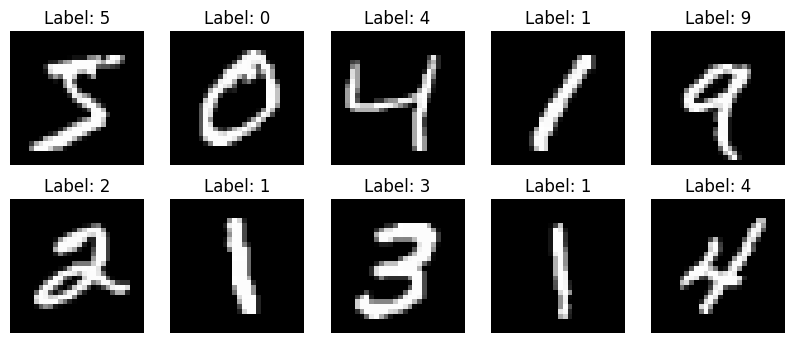

In [ ]:

# Carregar dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Formato do treino:", x_train.shape)
print("Formato do teste:", x_test.shape)

# Mostrar alguns exemplos
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()


## 3. Pré-processamento dos dados

In [ ]:

# Normalizar pixels (0-255 -> 0-1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten: transformar 28x28 -> vetor 784
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

print("Novo formato treino:", x_train.shape)


Novo formato treino: (60000, 784)


## 4. Criando a rede neural

In [ ]:

model = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(784,)),  # camada oculta
    layers.Dense(64, activation="relu"),                       # outra camada oculta
    layers.Dense(10, activation="softmax")                     # saída (10 classes)
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Treinando o modelo

In [ ]:

history = model.fit(x_train, y_train,
                    validation_split=0.1,
                    epochs=5,
                    batch_size=32)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9253 - loss: 0.2569 - val_accuracy: 0.9648 - val_loss: 0.1230
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9661 - loss: 0.1086 - val_accuracy: 0.9708 - val_loss: 0.0949
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9770 - loss: 0.0748 - val_accuracy: 0.9698 - val_loss: 0.0988
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9824 - loss: 0.0563 - val_accuracy: 0.9780 - val_loss: 0.0759
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9845 - loss: 0.0468 - val_accuracy: 0.9763 - val_loss: 0.0872


## 6. Avaliando no conjunto de teste

In [ ]:

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Acurácia no teste: {test_acc*100:.2f}%")


313/313 - 1s - 2ms/step - accuracy: 0.9741 - loss: 0.0857
Acurácia no teste: 97.41%


## 7. Fazendo previsões em novas imagens

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


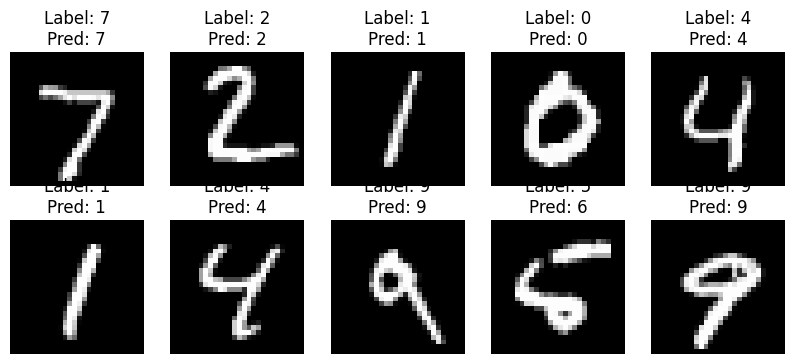

In [ ]:

predictions = model.predict(x_test[:10])

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title(f"Label: {y_test[i]}\nPred: {np.argmax(predictions[i])}")
    plt.axis("off")
plt.show()



## 8. Conexão com a teoria

- No **Vídeo teórico** vimos *por que* redes neurais são inspiradas no cérebro e como elas revolucionaram a IA.  
- Aqui vimos isso na prática: uma rede simples foi capaz de **aprender a reconhecer dígitos** sem que tivéssemos que programar regras manualmente.  
- Esse mesmo princípio pode ser usado em problemas de visão computacional, reconhecimento de voz, processamento de linguagem natural e muito mais.


Faça o upload das suas imagens de dígitos manuscritos (JPEG ou PNG):


Saving numero123321234.png to numero123321234 (1).png
Saving numero4423332334.png to numero4423332334 (1).png
Saving numero2323214234.png to numero2323214234 (1).png
Saving numero562234234.png to numero562234234 (1).png
Saving numero5675675675.png to numero5675675675 (1).png
Processando imagem: numero123321234 (1).png
Processando imagem: numero4423332334 (1).png
Processando imagem: numero2323214234 (1).png
Processando imagem: numero562234234 (1).png
Processando imagem: numero5675675675 (1).png
Total de imagens processadas: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


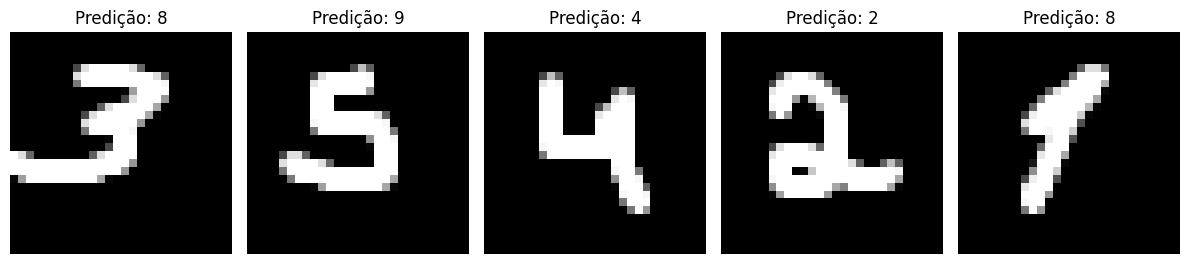

In [ ]:
from google.colab import files
from PIL import Image
import io

# Faz o upload das imagens
print("Faça o upload das suas imagens de dígitos manuscritos (JPEG ou PNG):")
uploaded = files.upload()

new_images = []
image_names = []

for fn in uploaded.keys():
    print(f'Processando imagem: {fn}')
    # Lê a imagem e a converte para um objeto PIL Image
    img = Image.open(io.BytesIO(uploaded[fn]))

    # Converte para escala de cinza, redimensiona para 28x28 e normaliza
    img = img.convert('L') # Converte para escala de cinza
    img = img.resize((28, 28)) # Redimensiona para 28x28
    img_array = np.array(img).astype('float32') / 255.0 # Converte para numpy array e normaliza

    # Inverte as cores se o fundo for branco (MNIST tem fundo preto)
    # Você pode precisar ajustar isso dependendo das suas imagens
    if img_array.mean() > 0.5: # Se a imagem for predominantemente clara, inverte
        img_array = 1.0 - img_array

    # Flatten (achata) a imagem para 784 pixels
    img_flat = img_array.reshape(1, 28*28)

    new_images.append(img_flat)
    image_names.append(fn)

if new_images:
    new_images_processed = np.vstack(new_images) # Combina todas as imagens em um único array
    print(f"Total de imagens processadas: {new_images_processed.shape[0]}")

    # Faz as previsões com o modelo treinado
    new_predictions = model.predict(new_images_processed)

    plt.figure(figsize=(12, 6))
    for i in range(len(image_names)):
        plt.subplot(2, 5, i + 1) # Ajuste o grid conforme necessário
        plt.imshow(new_images_processed[i].reshape(28, 28), cmap="gray")
        predicted_label = np.argmax(new_predictions[i])
        plt.title(f"Predição: {predicted_label}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma imagem foi carregada.")
